In [1]:
import uproot
import os
import dask_awkward as dak
import awkward as ak
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from matplotlib.ticker import PercentFormatter, FormatStrFormatter
import mplhep as hep
from dask.diagnostics import ProgressBar
import xgboost as xgb
import optuna
import cupy as cp
from optuna.samplers import TPESampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc
import joblib

In [2]:
plt.style.use(hep.style.CMS)

In [3]:
tree_path = "Events"
data_files = {f: tree_path for f in [
    "/eos/user/t/tdeandra/skim_outputs/Merged_Eras/Merged_dados_Run2022C.root",
    "/eos/user/t/tdeandra/skim_outputs/Merged_Eras/Merged_dados_Run2022D.root",
    "/eos/user/t/tdeandra/skim_outputs/Merged_Eras/Merged_dados_Run2022E.root",
    "/eos/user/t/tdeandra/skim_outputs/Merged_Eras/Merged_dados_Run2022F.root",
    "/eos/user/t/tdeandra/skim_outputs/Merged_Eras/Merged_dados_Run2022G.root"
]}

mc_files = {f: tree_path for f in [
    "/eos/user/t/tdeandra/skim_outputs/Merged_Eras/Merged_mc_signal_2022.root",
    "/eos/user/t/tdeandra/skim_outputs/Merged_Eras/Merged_mc_signal_2022EE.root"
]}

In [4]:
def get_b0_truth_mask(df):
    # --- 1. Constantes PDG ---
    PDG_B0        = 511
    PDG_KSTAR     = 313
    PDG_KAON_plus = 321
    PDG_PION_neg  = -211
    PDG_MUON_plus = -13
    PDG_MUON_neg  = 13
    PDG_PHOTON    = 22

    mu1_idx  = df["BPH_1Muon_genPartIdx"]
    mu2_idx  = df["BPH_2Muon_genPartIdx"]
    trk1_idx = df["Trk1_genPartIdx"]
    trk2_idx = df["Trk2_genPartIdx"]

    # Verificação de Identidade (PDG ID)
    mu1_pdg  = df["BPHGenPart_pdgId"][dak.mask(mu1_idx, mu1_idx >= 0)]
    mu2_pdg  = df["BPHGenPart_pdgId"][dak.mask(mu2_idx, mu2_idx >= 0)]
    trk1_pdg = df["BPHGenPart_pdgId"][dak.mask(trk1_idx, trk1_idx >= 0)]
    trk2_pdg = df["BPHGenPart_pdgId"][dak.mask(trk2_idx, trk2_idx >= 0)]

    flavor_match = (trk1_pdg == PDG_KAON_plus) & (trk2_pdg == PDG_PION_neg) & \
                   (mu1_pdg == PDG_MUON_plus) & (mu2_pdg == PDG_MUON_neg)

    # Linhagem do Hadron (K, Pi -> K* -> B0)
    mom_trk1_idx = df["BPHGenPart_genPartIdxMother"][dak.mask(trk1_idx, trk1_idx >= 0)]
    mom_trk2_idx = df["BPHGenPart_genPartIdxMother"][dak.mask(trk2_idx, trk2_idx >= 0)]
    
    mom_trk1_pdg = df["BPHGenPart_pdgId"][dak.mask(mom_trk1_idx, mom_trk1_idx >= 0)]
    mom_trk2_pdg = df["BPHGenPart_pdgId"][dak.mask(mom_trk2_idx, mom_trk2_idx >= 0)]
    
    # K e Pi devem vir do mesmo objeto K*0
    match_kstar = (mom_trk1_idx == mom_trk2_idx) & (mom_trk1_idx >= 0) & \
                  (mom_trk1_pdg == PDG_KSTAR) & (mom_trk2_pdg == PDG_KSTAR)
    
    # O K*0 deve vir de um B0
    gmom_trk1_idx = df["BPHGenPart_genPartIdxMother"][dak.mask(mom_trk1_idx, mom_trk1_idx >= 0)]
    gmom_trk2_idx = df["BPHGenPart_genPartIdxMother"][dak.mask(mom_trk2_idx, mom_trk2_idx >= 0)]
    
    gmom_trk1_pdg = df["BPHGenPart_pdgId"][dak.mask(gmom_trk1_idx, gmom_trk1_idx >= 0)]
    gmom_trk2_pdg = df["BPHGenPart_pdgId"][dak.mask(gmom_trk2_idx, gmom_trk2_idx >= 0)]
    
    match_kstar_to_b0 = (gmom_trk1_idx == gmom_trk2_idx) & (gmom_trk1_idx >= 0) & \
                        (gmom_trk1_pdg == PDG_B0) & (gmom_trk2_pdg == PDG_B0)

    mom_mu1_idx = df["BPHGenPart_genPartIdxMother"][dak.mask(mu1_idx, mu1_idx >= 0)]
    mom_mu2_idx = df["BPHGenPart_genPartIdxMother"][dak.mask(mu2_idx, mu2_idx >= 0)]
    mom_mu1_pdg = df["BPHGenPart_pdgId"][dak.mask(mom_mu1_idx, mom_mu1_idx >= 0)]
    mom_mu2_pdg = df["BPHGenPart_pdgId"][dak.mask(mom_mu2_idx, mom_mu2_idx >= 0)]
    
    gmom_mu1_idx = df["BPHGenPart_genPartIdxMother"][dak.mask(mom_mu1_idx, mom_mu1_idx >= 0)]
    gmom_mu2_idx = df["BPHGenPart_genPartIdxMother"][dak.mask(mom_mu2_idx, mom_mu2_idx >= 0)]

    # Muon 1: Mae e o B0 do hadron OU (Mae e foton e Avo e o B0 do hadron)
    mu1_from_same_b0 = (mom_mu1_idx == gmom_trk1_idx) | \
                       ((mom_mu1_pdg == PDG_PHOTON) & (gmom_mu1_idx == gmom_trk1_idx))

    mu2_from_same_b0 = (mom_mu2_idx == gmom_trk1_idx) | \
                       ((mom_mu2_pdg == PDG_PHOTON) & (gmom_mu2_idx == gmom_trk1_idx))

    # --- Mascara Final ---
    full_mask = flavor_match & match_kstar & match_kstar_to_b0 & \
                mu1_from_same_b0 & mu2_from_same_b0
    
    return ak.fill_none(full_mask, False)

In [5]:
def add_derived_columns(df):
    df["BToTrkTrkMuMu_l_xy_sig"]   = df['BToTrkTrkMuMu_l_xy']    / df['BToTrkTrkMuMu_l_xy_unc']
    df["BToTrkTrkMuMu_dca_sig"]    = df['BToTrkTrkMuMu_dca']     / df['BToTrkTrkMuMu_dcaErr']
    df["BToTrkTrkMuMu_trk1_dca_sig"] = df['BToTrkTrkMuMu_trk1_dca'] / df['BToTrkTrkMuMu_trk1_dcaErr']
    df["BToTrkTrkMuMu_trk2_dca_sig"] = df['BToTrkTrkMuMu_trk2_dca'] / df['BToTrkTrkMuMu_trk2_dcaErr']
    return df

In [6]:
def apply_selection(df, mode="mc"):

    kstar_pdg = 0.892
    mask_kpi_window = abs(df['BToTrkTrkMuMu_fit_ditrack_mass_Kpi'] - kstar_pdg) <= 0.150
    mask_pik_window = abs(df['BToTrkTrkMuMu_fit_ditrack_mass_piK'] - kstar_pdg) <= 0.150
    is_kpi_closer = abs(df['BToTrkTrkMuMu_fit_ditrack_mass_Kpi'] - kstar_pdg) < \
                    abs(df['BToTrkTrkMuMu_fit_ditrack_mass_piK'] - kstar_pdg)
    
    mask = (
        # Filtro de massa de dimuons (regiões de sinal, excluindo J/psi e Psi2S)
        (((df['MuMu_mass'] > 1.0) & (df['MuMu_mass'] < 2.7)) | 
         ((df['MuMu_mass'] > 4.0) & (df['MuMu_mass'] < 6.0))) & 
        
        # Pelo menos uma das combinações deve estar na janela de 3 sigma
        (mask_kpi_window | mask_pik_window) & 
        
        # Aplicamos a lógica de decisão de sabor (escolhemos a hipótese Kpi se ela for a melhor)
        (is_kpi_closer) &
        
        # Trigger e cortes cinemáticos dos múons
        (df['HLT_DoubleMu4_3_LowMass'] == 1) & 
        (df['BPH_1Muon_pt'] > 2.0) & (df['BPH_2Muon_pt'] > 2.0) & 
        (abs(df['BPH_1Muon_eta']) < 2.4) & (abs(df['BPH_2Muon_eta']) < 2.4) &
        (df['BToTrkTrkMuMu_fit_trk1_pt'] > 1.5) &
        (df['BToTrkTrkMuMu_fit_trk2_pt'] > 1.5) 
    )
    if mode == "mc":
        mask = mask & (df['BToTrkTrkMuMu_fit_mass_Kpi'] >= 5.1251) & (df['BToTrkTrkMuMu_fit_mass_Kpi'] <= 5.4351)
        mask = mask & get_b0_truth_mask(df) # No MC junta a mask de thruth Matching !!!
    else:
        mask = mask & (
            ((df['BToTrkTrkMuMu_fit_mass_Kpi'] > 5.0) & (df['BToTrkTrkMuMu_fit_mass_Kpi'] < 5.1251)) | 
            ((df['BToTrkTrkMuMu_fit_mass_Kpi'] > 5.4351) & (df['BToTrkTrkMuMu_fit_mass_Kpi'] < 5.6))
        )
    
    if mode == "mc":
        cols_to_keep = [
            'BToTrkTrkMuMu_l_xy_sig', 'BToTrkTrkMuMu_dca_sig',
            'BToTrkTrkMuMu_trk1_dca_sig', 'BToTrkTrkMuMu_trk2_dca_sig',
            'BToTrkTrkMuMu_fit_ditrack_mass_Kpi',
            'BToTrkTrkMuMu_fit_pt', 'BToTrkTrkMuMu_fit_cos2D', 'BToTrkTrkMuMu_svprob',
            'event', 'Pileup_nTrueInt'
        ]
    else:
        cols_to_keep = [
            'BToTrkTrkMuMu_l_xy_sig', 'BToTrkTrkMuMu_dca_sig',
            'BToTrkTrkMuMu_trk1_dca_sig', 'BToTrkTrkMuMu_trk2_dca_sig',
            'BToTrkTrkMuMu_fit_ditrack_mass_Kpi',
            'BToTrkTrkMuMu_fit_pt', 'BToTrkTrkMuMu_fit_cos2D', 'BToTrkTrkMuMu_svprob',
            'event'
        ]
        
    return df[cols_to_keep][mask]

In [7]:
def build_dataframe(file_dict, label="Dataset", mode="mc"):
    print(f"\nProcessando {label}...")

    df = uproot.dask(file_dict)
    df = add_derived_columns(df)
    df = apply_selection(df, mode=mode)

    with ProgressBar():
        awkward_array = df.compute()
        df_pandas = ak.to_dataframe(awkward_array).reset_index(drop=True)

    initial_len = len(df_pandas)
    df_pandas = df_pandas.replace([np.inf, -np.inf], np.nan)
    df_pandas = df_pandas.dropna()
    final_len  = len(df_pandas)
    removed    = initial_len - final_len

    if removed > 0:
        print(f"  [Limpeza] Removidos {removed} eventos com NaN ou Inf ({removed/initial_len:.2%})")

    print(f"{label} finalizado. Linhas: {final_len}")
    return df_pandas

In [8]:
df_data = build_dataframe(data_files, "Data (Sidebands)", mode="data")
df_mc   = build_dataframe(mc_files,   "MC Signal (Truth Matched)", mode="mc")

print(f"\nEventos de background (sidebands): {len(df_data)}")
print(f"Eventos de sinal (MC truth):        {len(df_mc)}")
print(f"Razao bkg/sig: {len(df_data)/len(df_mc):.1f}")


Processando Data (Sidebands)...
[########################################] | 100% Completed | 206.75 ms
[                                        ] | 0% Completed | 123.38 ss

/cvmfs/sft.cern.ch/lcg/views/LCG_109_cuda/x86_64-el9-gcc13-opt/lib/python3.13/site-packages/awkward/_nplikes/array_module.py:285: RuntimeWarning: divide by zero encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


[########################################] | 100% Completed | 18m 10s
  [Limpeza] Removidos 2 eventos com NaN ou Inf (0.00%)
Data (Sidebands) finalizado. Linhas: 88915

Processando MC Signal (Truth Matched)...
[########################################] | 100% Completed | 315.23 ms
[                                        ] | 0% Completed | 44.16 sms

/cvmfs/sft.cern.ch/lcg/views/LCG_109_cuda/x86_64-el9-gcc13-opt/lib/python3.13/site-packages/awkward/_nplikes/array_module.py:285: RuntimeWarning: divide by zero encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


[########################################] | 100% Completed | 49.33 s
  [Limpeza] Removidos 37 eventos com NaN ou Inf (0.02%)
MC Signal (Truth Matched) finalizado. Linhas: 185126

Eventos de background (sidebands): 88915
Eventos de sinal (MC truth):        185126
Razao bkg/sig: 0.5


In [9]:
pu_weight_arr = np.load("/eos/user/t/tdeandra/SWAN_projects/BPH_Analysis/MC_Analysis/Pileup_Correction/mc_weight.npy")

bins       = np.floor(df_mc['Pileup_nTrueInt'] + 0.5).astype(int)
valid_mask = (bins >= 0) & (bins < len(pu_weight_arr))

df_mc['pu_weight'] = 1.0
df_mc.loc[valid_mask, 'pu_weight'] = pu_weight_arr[bins[valid_mask]]
df_mc = df_mc.drop(columns=['Pileup_nTrueInt'])

In [10]:
df_mc['total_weight']   = df_mc['pu_weight'] # x outros SFs (ID, HLT, etc.) quando disponiveis
df_data['total_weight'] = 1.0                 # Aqui não há correção 

In [11]:
df_data["label"] = 0  # background
df_mc["label"]   = 1  # sinal

In [12]:
df_combined = pd.concat([df_data, df_mc], ignore_index=True)
df_combined = df_combined.sample(frac=1, random_state=42).reset_index(drop=True)

# Fold ID deterministico por numero de evento (conforme a AN)
df_combined['fold_id'] = df_combined['event'] % 5

In [13]:
# features disponiveis que vou usar
features = [
    'BToTrkTrkMuMu_l_xy_sig',
    'BToTrkTrkMuMu_dca_sig',
    'BToTrkTrkMuMu_trk1_dca_sig',
    'BToTrkTrkMuMu_trk2_dca_sig',
    'BToTrkTrkMuMu_fit_ditrack_mass_Kpi',
    'BToTrkTrkMuMu_fit_pt',
    'BToTrkTrkMuMu_fit_cos2D',
    'BToTrkTrkMuMu_svprob',
]

In [14]:
def calc_punzi_smin_imp(B, a=2.0, b=5.0):
    """Punzi pseudo-significance (Eq. 17 de arXiv:physics/0308063)."""
    term1 = (a**2) / 8.0
    term2 = (9.0 * (b**2)) / 13.0
    term3 = a * np.sqrt(B)
    term4 = (b / 2.0) * np.sqrt((b**2) + 4*a*np.sqrt(B) + 4*B)
    return term1 + term2 + term3 + term4

In [15]:
def evaluate_punzi_scan(y_true, preds, w_phys, a=2.0, b=5.0):
    """Calcula o melhor Punzi FOM varrendo working points.
    Conforme a nota: nsig/nbkg calculados APENAS no fold de teste (dados independentes)."""
    y_true = np.asarray(y_true)
    preds  = np.asarray(preds)
    w_phys = np.asarray(w_phys)

    thresholds = np.linspace(0., 1, 100)
    S_total    = w_phys[y_true == 1].sum()
    melhor_punzi = np.inf

    for cut in thresholds:
        passou   = preds > cut
        B_pass   = w_phys[(y_true == 0) & passou].sum()
        S_pass   = w_phys[(y_true == 1) & passou].sum()
        epsilon  = S_pass / S_total if S_total > 0 else 0

        if epsilon < 0.01 or B_pass <= 0:
            continue

        s_min  = calc_punzi_smin_imp(B_pass, a=a, b=b)
        target = s_min / epsilon
        if target < melhor_punzi:
            melhor_punzi = target

    return melhor_punzi

In [16]:
def objective(trial, X_data, y_data, w_data, fold_ids):
    """Funcao objetivo para o Optuna.

    CORRECAO principal: o Punzi agora e calculado APENAS sobre os eventos do
    fold de teste de cada iteracao (eventos que o modelo nao viu durante o
    treinamento). Isso evita o data leakage que causava Training == Test.
    """
    param = {
        'max_depth':        trial.suggest_int('max_depth', 1, 10),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.1, 1.0),
        'min_child_weight': trial.suggest_float('min_child_weight', 0.1, 10.0),
        'n_estimators':     trial.suggest_int('n_estimators', 100, 1000),
        'scale_pos_weight': w_data[y_data == 0].sum() / w_data[y_data == 1].sum(),
        'tree_method':      'hist',   
        'device':           'cuda',   
        'objective':        'binary:logistic',
        'random_state':     42,
        'verbosity':        0,
    }

    # Mover dados para GPU uma unica vez
    X_gpu    = cp.array(X_data.values)
    y_gpu    = cp.array(y_data.values)
    w_gpu    = cp.array(w_data.values)
    folds_gpu = cp.array(fold_ids.values)

    # --- CORRECAO: acumular predicoes APENAS nos folds de teste ---
    preds_test_all = np.zeros(len(y_gpu))
    in_test        = np.zeros(len(y_gpu), dtype=bool)

    for i in range(5):
        train_mask = (folds_gpu != i)
        test_mask  = (folds_gpu == i)

        model = xgb.XGBClassifier(**param)
        model.fit(
            X_gpu[train_mask], y_gpu[train_mask],
            sample_weight=w_gpu[train_mask]
        )

        # Predicoes apenas para o fold de teste (dados independentes)
        test_idx_cpu = cp.asnumpy(cp.where(test_mask)[0])
        preds_test_all[test_idx_cpu] = cp.asnumpy(
            model.predict_proba(X_gpu[test_mask])[:, 1]
        )
        in_test[test_idx_cpu] = True

    # Avaliacao do Punzi sobre o conjunto de teste completo (sem leakage)
    y_cpu = y_data.values
    w_cpu = w_data.values

    return evaluate_punzi_scan(y_cpu[in_test], preds_test_all[in_test], w_cpu[in_test])

In [17]:
X = df_combined[features]
y = df_combined['label']
w = df_combined['total_weight']
f = df_combined['fold_id']

In [18]:
study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(lambda trial: objective(trial, X, y, w, f), n_trials=200, show_progress_bar=True)

[I 2026-05-05 15:41:34,649] A new study created in memory with name: no-name-3855be6c-95cc-46c9-be07-790e466b134c


  0%|          | 0/200 [00:00<?, ?it/s]

[I 2026-05-05 15:41:44,431] Trial 0 finished with value: 276.29323562622665 and parameters: {'max_depth': 4, 'learning_rate': 0.28570714885887566, 'subsample': 0.8659969709057025, 'colsample_bytree': 0.6387926357773329, 'min_child_weight': 1.6445845403801216, 'n_estimators': 240}. Best is trial 0 with value: 276.29323562622665.
[I 2026-05-05 15:41:48,141] Trial 1 finished with value: 267.62813341047274 and parameters: {'max_depth': 1, 'learning_rate': 0.2611910822747312, 'subsample': 0.8005575058716043, 'colsample_bytree': 0.737265320016441, 'min_child_weight': 0.3037864935284442, 'n_estimators': 973}. Best is trial 1 with value: 267.62813341047274.
[I 2026-05-05 15:42:02,501] Trial 2 finished with value: 278.2676349082663 and parameters: {'max_depth': 9, 'learning_rate': 0.07157834209670008, 'subsample': 0.5909124836035503, 'colsample_bytree': 0.2650640588680905, 'min_child_weight': 3.1119982052994235, 'n_estimators': 572}. Best is trial 1 with value: 267.62813341047274.
[I 2026-05-05

In [19]:
print("\n--- Resultado da Otimizacao ---")
print(f"Melhor valor de Punzi: {study.best_value:.4f}")
print(f"Melhores parametros:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")


--- Resultado da Otimizacao ---
Melhor valor de Punzi: 255.1248
Melhores parametros:
  max_depth: 2
  learning_rate: 0.06399129169660278
  subsample: 0.6603971709921014
  colsample_bytree: 0.34459730558109536
  min_child_weight: 9.400996050408725
  n_estimators: 850


In [20]:
best_params = study.best_params.copy()
best_params['objective']        = 'binary:logistic'
best_params['eval_metric']      = ['logloss', 'auc']
best_params['tree_method']      = 'hist'
best_params['device']           = 'cuda'
best_params['random_state']     = 42
best_params['scale_pos_weight'] = w[y == 0].sum() / w[y == 1].sum()

In [21]:
os.makedirs("bdt_models_final", exist_ok=True)

In [22]:
all_histories = []
df_combined['final_bdt_score'] = -1.0

print("\nIniciando o Treinamento Final dos 5 Folds...")

for i in range(5):
    mask_test = df_combined['fold_id'] == i

    # Split 70/30 treino/validacao dentro dos 10 folds de treino (conforme a nota)
    idx_tv = df_combined[~mask_test].index
    train_idx, val_idx = train_test_split(
        idx_tv,
        test_size=0.3,
        random_state=42,
        stratify=df_combined.loc[idx_tv, 'label']
    )

    # Preparacao na GPU
    X_train = cp.array(df_combined.loc[train_idx, features].values)
    y_train = cp.array(df_combined.loc[train_idx, 'label'].values)
    w_train = cp.array(df_combined.loc[train_idx, 'total_weight'].values)

    X_val   = cp.array(df_combined.loc[val_idx, features].values)
    y_val   = cp.array(df_combined.loc[val_idx, 'label'].values)
    w_val   = cp.array(df_combined.loc[val_idx, 'total_weight'].values)

    X_analysis = cp.array(df_combined.loc[mask_test, features].values)

    clf = xgb.XGBClassifier(**best_params, early_stopping_rounds=30)

    clf.fit(
        X_train, y_train,
        sample_weight=w_train,
        eval_set=[(X_train, y_train), (X_val, y_val)],
        sample_weight_eval_set=[w_train, w_val],
        verbose=False
    )

    all_histories.append(clf.evals_result())

    # Predicao para o fold de analise (independente)
    preds_gpu = clf.predict_proba(X_analysis)[:, 1]
    df_combined.loc[mask_test, 'final_bdt_score'] = cp.asnumpy(preds_gpu)

    model_filename = f"bdt_models_final/xgboost_fold_{i}.joblib"
    joblib.dump(clf, model_filename)

    print(f"  -> Fold {i} treinado (Best tree: {clf.best_iteration}) - salvo em {model_filename}")

print("\nTreinamento concluido. Coluna 'final_bdt_score' preenchida.")


Iniciando o Treinamento Final dos 5 Folds...
  -> Fold 0 treinado (Best tree: 795) - salvo em bdt_models_final/xgboost_fold_0.joblib
  -> Fold 1 treinado (Best tree: 844) - salvo em bdt_models_final/xgboost_fold_1.joblib
  -> Fold 2 treinado (Best tree: 721) - salvo em bdt_models_final/xgboost_fold_2.joblib
  -> Fold 3 treinado (Best tree: 806) - salvo em bdt_models_final/xgboost_fold_3.joblib
  -> Fold 4 treinado (Best tree: 849) - salvo em bdt_models_final/xgboost_fold_4.joblib

Treinamento concluido. Coluna 'final_bdt_score' preenchida.


/cvmfs/sft.cern.ch/lcg/views/LCG_109_cuda/x86_64-el9-gcc13-opt/lib/python3.13/site-packages/xgboost/core.py:158: UserWarning: [15:58:13] WARNING: /build/jenkins/workspace/lcg_release_pipeline/build/pyexternals/xgboost-2.1.3/src/xgboost/2.1.3/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)


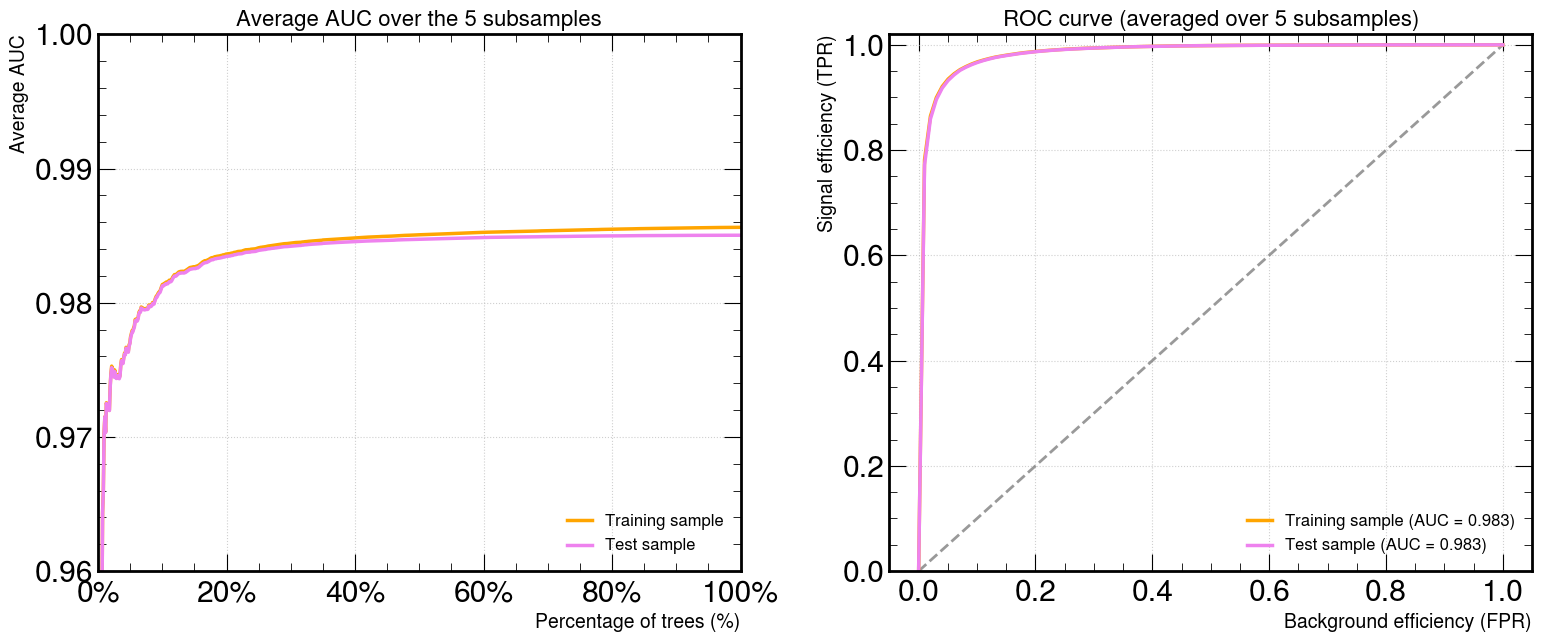

AUC treino: 0.983 | AUC teste: 0.983


In [23]:
# ==============================================================================
# 1. CURVA DE APRENDIZAGEM MEDIA (AUC vs % de arvores)
# ==============================================================================
max_epochs = max([len(h['validation_0']['auc']) for h in all_histories])

train_auc_matrix = np.zeros((5, max_epochs))
val_auc_matrix   = np.zeros((5, max_epochs))

for i, h in enumerate(all_histories):
    t_auc = h['validation_0']['auc']
    v_auc = h['validation_1']['auc']
    train_auc_matrix[i, :len(t_auc)] = t_auc
    val_auc_matrix[i,   :len(v_auc)] = v_auc
    if len(t_auc) < max_epochs:
        train_auc_matrix[i, len(t_auc):] = t_auc[-1]
        val_auc_matrix[i,   len(v_auc):] = v_auc[-1]

mean_train_auc_history = np.mean(train_auc_matrix, axis=0)
mean_val_auc_history   = np.mean(val_auc_matrix,   axis=0)

# ==============================================================================
# 2. CURVA ROC MEDIA (Train vs Test)
# A curva de treino usa APENAS os 70% de treino (mesmo split da Cell 21),
# garantindo comparacao honesta com o fold de teste independente.
# ==============================================================================
tprs_train = []
tprs_test  = []
mean_fpr   = np.linspace(0, 1, 100)

for i in range(5):
    mask_test = df_combined['fold_id'] == i

    # Recria o mesmo split 70/30 da Cell 21 (mesmo random_state e stratify)
    idx_tv = df_combined[~mask_test].index
    train_idx, _ = train_test_split(
        idx_tv,
        test_size=0.3,
        random_state=42,
        stratify=df_combined.loc[idx_tv, 'label']
    )

    df_train_only = df_combined.loc[train_idx]   # ← apenas os 70% que o modelo viu
    df_test       = df_combined[mask_test]

    model = joblib.load(f"bdt_models_final/xgboost_fold_{i}.joblib")

    y_train_pred = model.predict_proba(df_train_only[features])[:, 1]
    y_test_pred  = model.predict_proba(df_test[features])[:, 1]

    fpr_train, tpr_train, _ = roc_curve(df_train_only['label'], y_train_pred)
    interp_tpr_train        = np.interp(mean_fpr, fpr_train, tpr_train)
    interp_tpr_train[0]     = 0.0
    tprs_train.append(interp_tpr_train)

    fpr_test, tpr_test, _   = roc_curve(df_test['label'], y_test_pred)
    interp_tpr_test         = np.interp(mean_fpr, fpr_test, tpr_test)
    interp_tpr_test[0]      = 0.0
    tprs_test.append(interp_tpr_test)

mean_tpr_train     = np.mean(tprs_train, axis=0)
mean_tpr_train[-1] = 1.0
mean_auc_train     = auc(mean_fpr, mean_tpr_train)

mean_tpr_test      = np.mean(tprs_test, axis=0)
mean_tpr_test[-1]  = 1.0
mean_auc_test      = auc(mean_fpr, mean_tpr_test)

# ==============================================================================
# 3. PLOTAGEM (estilo CMS AN)
# ==============================================================================
fig, ax = plt.subplots(1, 2, figsize=(16, 7))

epochs_percent = np.linspace(0, 100, max_epochs)

ax[0].plot(epochs_percent, mean_train_auc_history, color='orange', lw=2.5, label='Training sample')
ax[0].plot(epochs_percent, mean_val_auc_history,   color='violet', lw=2.5, label='Test sample')
ax[0].xaxis.set_major_formatter(PercentFormatter(100))
ax[0].set_xlabel('Percentage of trees (%)', fontsize=14)
ax[0].set_ylabel('Average AUC', fontsize=14)
ax[0].set_title('Average AUC over the 5 subsamples', fontsize=16)
ax[0].legend(loc='lower right', fontsize=12)
ax[0].grid(True, linestyle=':', alpha=0.6)
ax[0].set_xlim(0, 100)
ax[0].set_ylim(0.96, 1.0)

ax[1].plot([0, 1], [0, 1], linestyle='--', lw=2, color='gray', alpha=0.8)
ax[1].plot(mean_fpr, mean_tpr_train, color='orange', lw=2.5,
           label=f'Training sample (AUC = {mean_auc_train:.3f})')
ax[1].plot(mean_fpr, mean_tpr_test,  color='violet', lw=2.5,
           label=f'Test sample (AUC = {mean_auc_test:.3f})')
ax[1].set_xlabel('Background efficiency (FPR)', fontsize=14)
ax[1].set_ylabel('Signal efficiency (TPR)', fontsize=14)
ax[1].set_title('ROC curve (averaged over 5 subsamples)', fontsize=16)
ax[1].legend(loc='lower right', fontsize=12)
ax[1].grid(True, linestyle=':', alpha=0.6)
#ax[1].set_xlim([0, 1.02])
ax[1].set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig("bdt_averaged_roc_and_auc_percent.png", dpi=300)
plt.show()
print(f"AUC treino: {mean_auc_train:.3f} | AUC teste: {mean_auc_test:.3f}")

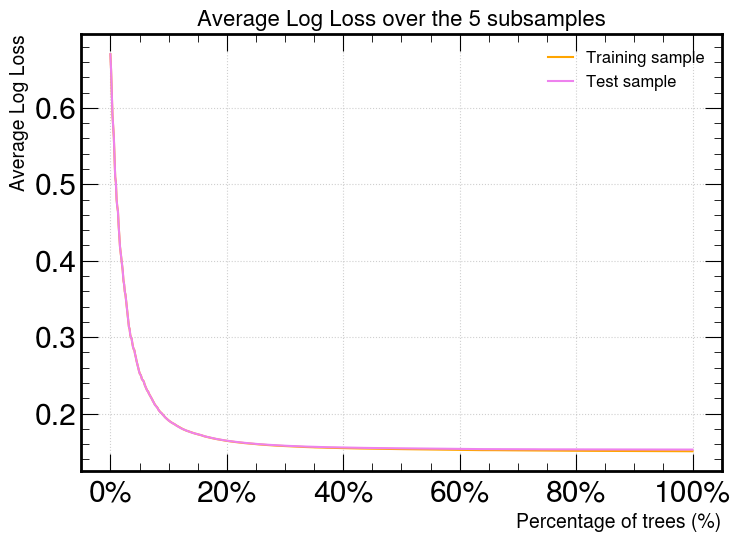

In [24]:
# ==============================================================================
# CURVA DE LOG LOSS MEDIA
# ==============================================================================
max_epochs_loss = max([len(h['validation_0']['logloss']) for h in all_histories])

train_loss_matrix = np.zeros((5, max_epochs_loss))
val_loss_matrix   = np.zeros((5, max_epochs_loss))

for i, h in enumerate(all_histories):
    t_loss = h['validation_0']['logloss']
    v_loss = h['validation_1']['logloss']
    train_loss_matrix[i, :len(t_loss)] = t_loss
    val_loss_matrix[i,   :len(v_loss)] = v_loss
    if len(t_loss) < max_epochs_loss:
        train_loss_matrix[i, len(t_loss):] = t_loss[-1]
        val_loss_matrix[i,   len(v_loss):] = v_loss[-1]

mean_train_loss_history = np.mean(train_loss_matrix, axis=0)
mean_val_loss_history   = np.mean(val_loss_matrix,   axis=0)

epochs_percent = np.linspace(0, 100, max_epochs_loss)

plt.figure(figsize=(8, 6))
plt.plot(epochs_percent, mean_train_loss_history, color='orange', lw=1.5, label='Training sample')
plt.plot(epochs_percent, mean_val_loss_history,   color='violet', lw=1.5, label='Test sample')
plt.gca().xaxis.set_major_formatter(PercentFormatter(100))
plt.xlabel('Percentage of trees (%)', fontsize=14)
plt.ylabel('Average Log Loss', fontsize=14)
plt.title('Average Log Loss over the 5 subsamples', fontsize=16)
plt.legend(loc='upper right', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig("bdt_averaged_logloss_percent.png", dpi=300)
plt.show()

Plot salvo como overtraining_check.png


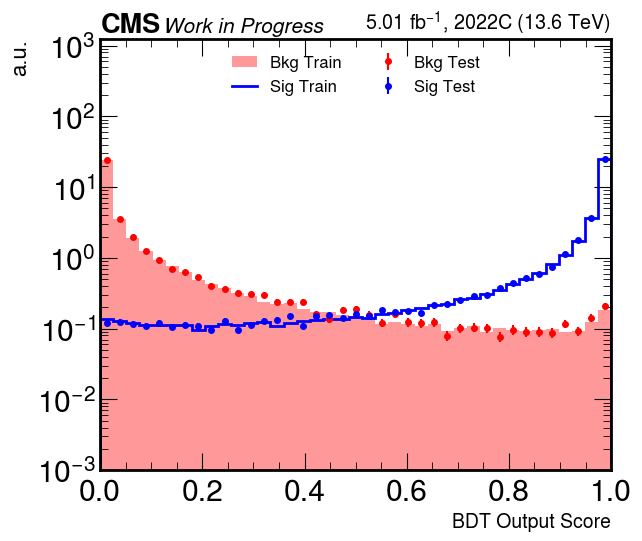

In [25]:
# ==============================================================================
# OVERTRAINING CHECK: distribuicao do BDT score (sinal e bkg, treino vs teste)
# Avalia apenas o fold 0 como exemplo representativo.
# ==============================================================================
fold_idx = 0

mask_test  = df_combined['fold_id'] == fold_idx
df_test    = df_combined[mask_test]
df_train   = df_combined[~mask_test]

model = joblib.load(f"bdt_models_final/xgboost_fold_{fold_idx}.joblib")

y_probs_train = model.predict_proba(df_train[features])[:, 1]
y_probs_test  = model.predict_proba(df_test[features])[:, 1]
y_train_lbl   = df_train['label'].values
y_test_lbl    = df_test['label'].values

sig_train = y_probs_train[y_train_lbl == 1]
bkg_train = y_probs_train[y_train_lbl == 0]
sig_test  = y_probs_test[y_test_lbl == 1]
bkg_test  = y_probs_test[y_test_lbl == 0]

fig, ax = plt.subplots(figsize=(7, 6))
bins_plot   = np.linspace(0, 1, 40)
bin_centers = 0.5 * (bins_plot[:-1] + bins_plot[1:])

# Background
h_bkg_train, _ = np.histogram(bkg_train, bins=bins_plot, density=True)
hep.histplot(h_bkg_train, bins=bins_plot, ax=ax, color='red', alpha=0.4,
             histtype='fill', label='Bkg Train')
h_bkg_test_counts, _ = np.histogram(bkg_test, bins=bins_plot)
h_bkg_test_dens,   _ = np.histogram(bkg_test, bins=bins_plot, density=True)
scale_bkg  = np.divide(h_bkg_test_dens, h_bkg_test_counts,
                        out=np.zeros_like(h_bkg_test_dens), where=h_bkg_test_counts != 0)
error_bkg  = np.sqrt(h_bkg_test_counts) * scale_bkg
ax.errorbar(bin_centers, h_bkg_test_dens, yerr=error_bkg, fmt='o',
            color='red', markersize=4, label='Bkg Test')

# Sinal
h_sig_train, _ = np.histogram(sig_train, bins=bins_plot, density=True)
hep.histplot(h_sig_train, bins=bins_plot, ax=ax, color='blue', linewidth=2,
             histtype='step', label='Sig Train')
h_sig_test_counts, _ = np.histogram(sig_test, bins=bins_plot)
h_sig_test_dens,   _ = np.histogram(sig_test, bins=bins_plot, density=True)
scale_sig  = np.divide(h_sig_test_dens, h_sig_test_counts,
                        out=np.zeros_like(h_sig_test_dens), where=h_sig_test_counts != 0)
error_sig  = np.sqrt(h_sig_test_counts) * scale_sig
ax.errorbar(bin_centers, h_sig_test_dens, yerr=error_sig, fmt='o',
            color='blue', markersize=4, label='Sig Test')

ax.set_yscale('log')
max_y = max(h_sig_train.max(), h_bkg_train.max())
ax.set_ylim(bottom=1e-3, top=max_y * 50)
ax.set_xlim(0, 1)
ax.set_xlabel("BDT Output Score", fontsize=14)
ax.set_ylabel("a.u.", fontsize=16)
ax.legend(loc='upper center', fontsize=12, ncol=2)

hep.cms.label(ax=ax, label="Work in Progress", data=True,
              lumi=5.01, year="2022C", com=13.6, fontsize=15)

plt.tight_layout()
plt.savefig("overtraining_check.png", dpi=300)
print("Plot salvo como overtraining_check.png")
plt.show()

<>:30: SyntaxWarning: invalid escape sequence '\p'
<>:30: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_393/1610359506.py:30: SyntaxWarning: invalid escape sequence '\p'
  'BToTrkTrkMuMu_fit_ditrack_mass_Kpi': '$m(K\pi)$',


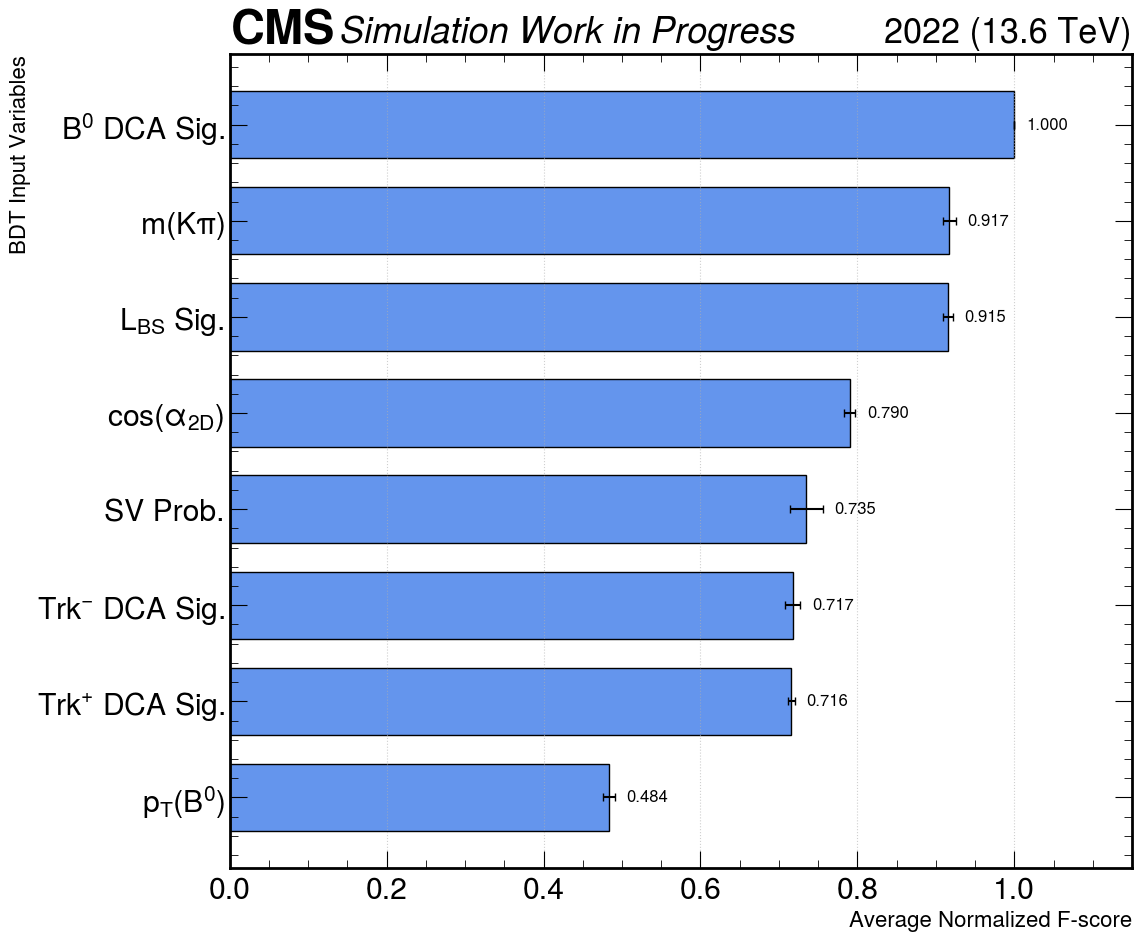

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mplhep as hep
import joblib
import seaborn as sns

# Konfigurer CMS stil
plt.style.use(hep.styles.CMS)

# ==============================================================================
# 0. DEFINITION AF FEATURES OG FORMATEREDE LABELS
# ==============================================================================
features = [
    'BToTrkTrkMuMu_l_xy_sig',
    'BToTrkTrkMuMu_dca_sig',
    'BToTrkTrkMuMu_trk1_dca_sig',
    'BToTrkTrkMuMu_trk2_dca_sig',
    'BToTrkTrkMuMu_fit_ditrack_mass_Kpi',
    'BToTrkTrkMuMu_fit_pt',
    'BToTrkTrkMuMu_fit_cos2D',
    'BToTrkTrkMuMu_svprob',
]

labels_dict = {
    'BToTrkTrkMuMu_l_xy_sig': '$L_{BS}$ Sig.',
    'BToTrkTrkMuMu_dca_sig': '$B^{0}$ DCA Sig.',
    'BToTrkTrkMuMu_trk1_dca_sig': r'$Trk^{+}$ DCA Sig.',
    'BToTrkTrkMuMu_trk2_dca_sig': r'$Trk^{-}$ DCA Sig.',
    'BToTrkTrkMuMu_fit_ditrack_mass_Kpi': '$m(K\pi)$',
    'BToTrkTrkMuMu_fit_pt': '$p_T(B^{0})$',
    'BToTrkTrkMuMu_fit_cos2D': r'$\cos(\alpha_{2D})$',
    'BToTrkTrkMuMu_svprob': 'SV Prob.'
}

# ==============================================================================
# 1. UDTRÆKNING OG NORMALISERING AF F-SCORES (WEIGHTS)
# ==============================================================================
normalized_scores_all_folds = {feat: [] for feat in features}

for i in range(5):
    model = joblib.load(f"bdt_models_final/xgboost_fold_{i}.joblib")
    booster = model.get_booster()
    
    # Udtræk 'weight' (F-score)
    raw_f_scores = booster.get_score(importance_type='weight')
    
    f_scores = {}
    for j, feat_name in enumerate(features):
        score_by_name = raw_f_scores.get(feat_name)
        score_by_f_idx = raw_f_scores.get(f'f{j}')
        f_scores[feat_name] = float(score_by_name or score_by_f_idx or 0.0)
    
    fold_scores = np.array([f_scores[feat] for feat in features])
    
    # Normalisering
    max_score = np.max(fold_scores)
    if max_score > 0:
        fold_scores_norm = fold_scores / max_score 
    else:
        fold_scores_norm = fold_scores
        
    for feat, score in zip(features, fold_scores_norm):
        normalized_scores_all_folds[feat].append(score)

# ==============================================================================
# 2. BEREGNING AF GENNEMSNIT OG PLOTNING (MED PRETTY LABELS)
# ==============================================================================
feat_stats = []
for feat in features:
    scores = normalized_scores_all_folds[feat]
    feat_stats.append({
        'feature': feat,
        'pretty_label': labels_dict.get(feat, feat), # Tilknytter det pæne label her
        'mean': np.mean(scores),
        'stderr': np.std(scores) / np.sqrt(5)
    })

# Opret DataFrame og sortér (fra mindst til størst)
df_plot = pd.DataFrame(feat_stats).sort_values(by='mean', ascending=True)

fig, ax = plt.subplots(figsize=(12, 10))

# Brug 'pretty_label' til Y-aksen i stedet for de rå navne
bars = ax.barh(df_plot['pretty_label'], df_plot['mean'], xerr=df_plot['stderr'], 
               color='cornflowerblue', edgecolor='black', height=0.7, capsize=3)

# Tilføj numeriske værdier ved siden af søjlerne
for i, row in enumerate(df_plot.itertuples()):
    ax.text(row.mean + row.stderr + 0.015, i, f'{row.mean:.3f}', 
            va='center', fontsize=12)

ax.set_xlabel('Average Normalized F-score', fontsize=16)
ax.set_ylabel('BDT Input Variables', fontsize=16)
ax.set_xlim(0, 1.15) 

hep.cms.label("Work in Progress", data=False, com=13.6, year = 2022, loc=0) 

plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig("feature_importance_hep_pretty_labels.png", dpi=300)
plt.show()